# PA-CCS latent separability — grid (4 metrics × 4 dataset families)

For **each** metric — **accuracy** (sign-corrected CCS), **silhouette**, **|PC|** (abs polar
consistency) and **CI** (contradiction index) — this notebook renders one figure with **4 panels**,
one per dataset family:

1. **`mixed_dataset`** — the polarity *mixed* set (8 registry models, via `analysis.load_ccs`).
2. **`toxigen_single`** — ToxiGen `single` format. *Single format has **no** opposite-polarity
   pairs, so `polar_consistency` / `contradiction_index` are **NaN by design***  → the **|PC|** and
   **CI** panels here are empty and annotated `N/A`.
3. **`toxigen_paired`** — ToxiGen `--with-negations` paired format.
4. **`toxigen by groups`** — the per-(target group) k-fold runs. The per-group CSV has **no CI
   column**, so the **CI** by-groups panel is empty and annotated `N/A`.

Panels 1–3 are **per-layer curves** (x = fractional depth = layer/(n_layers−1), one line per
model). Panel 4 is **per-target-group markers** (x = group, one marker series per model).

## Visual conventions
- **Colour = model family** (so the *base* and *instruct* variants of one family share a colour).
- **Line style / marker fill = variant**: **base = solid line / filled marker**,
  **instruct = dashed line / hollow marker** (—— base · - - instruct).
- Chance/random baselines from `analysis.py` are drawn as dotted grey lines (accuracy `0.5`,
  silhouette `≈0`, random-probe `|PC|≈0.17`, random-probe `CI≈0.5`).

## "Missing models" convention
The **expected** set for every panel is the **8 registry models** in `analysis.MODELS`. Each
figure's single, bottom-outside legend names the models, the base/instruct convention, the
baseline, **and explicitly lists which expected models are MISSING from each panel** (no run, or
the metric is undefined/not recorded for that dataset). The same present/missing breakdown is
printed below each figure.

## Saved outputs (high-resolution, `dpi=300`, `bbox_inches="tight"`)
- 4 **combined** 2×2 grids: `runs/figs/sep_grid_{accuracy,silhouette,pc,ci}.png`.
- 16 **standalone** panels (one per metric×dataset, each keeping its own bottom-outside legend and
  title): `runs/figs/sep_grid_<metric>_<dataset>.png` — ready to drop into a slide.

> Plotting logic lives in `runs/separability_grid.py` so these cells stay short.

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Make runs/ importable so we can reuse analysis.py + the grid helper.
RUNS = Path.cwd().parent / "runs"
if str(RUNS) not in sys.path:
    sys.path.insert(0, str(RUNS))

import separability_grid as G

# Load every CSV once and compute the chance baselines once; reused by all four figures.
DATASETS = G.build_datasets()
BASELINES = G._baselines()

FIGDIR = G.RUNS / "figs"
DPI = 300


def show(metric):
    """Build the metric's 2x2 grid, SAVE it (dpi=300), display it, and print the breakdown."""
    fig, report = G.make_figure(metric, datasets=DATASETS, baselines=BASELINES)
    combined = FIGDIR / G.METRIC_FNAME[metric]
    fig.savefig(combined, dpi=DPI, bbox_inches="tight")  # save, not only display
    plt.show()
    print(f"saved combined grid -> {combined}")
    print(f"present / missing per panel (expected = {len(G.EXPECTED)} registry models):")
    for dskey in G.DATASET_ORDER:
        rep = report[dskey]
        miss = ", ".join(rep["missing"]) if rep["missing"] else "none"
        print(f"  {dskey:16} present={len(rep['present'])}  missing: {miss}")
    return report

## 1. Accuracy (sign-corrected CCS)

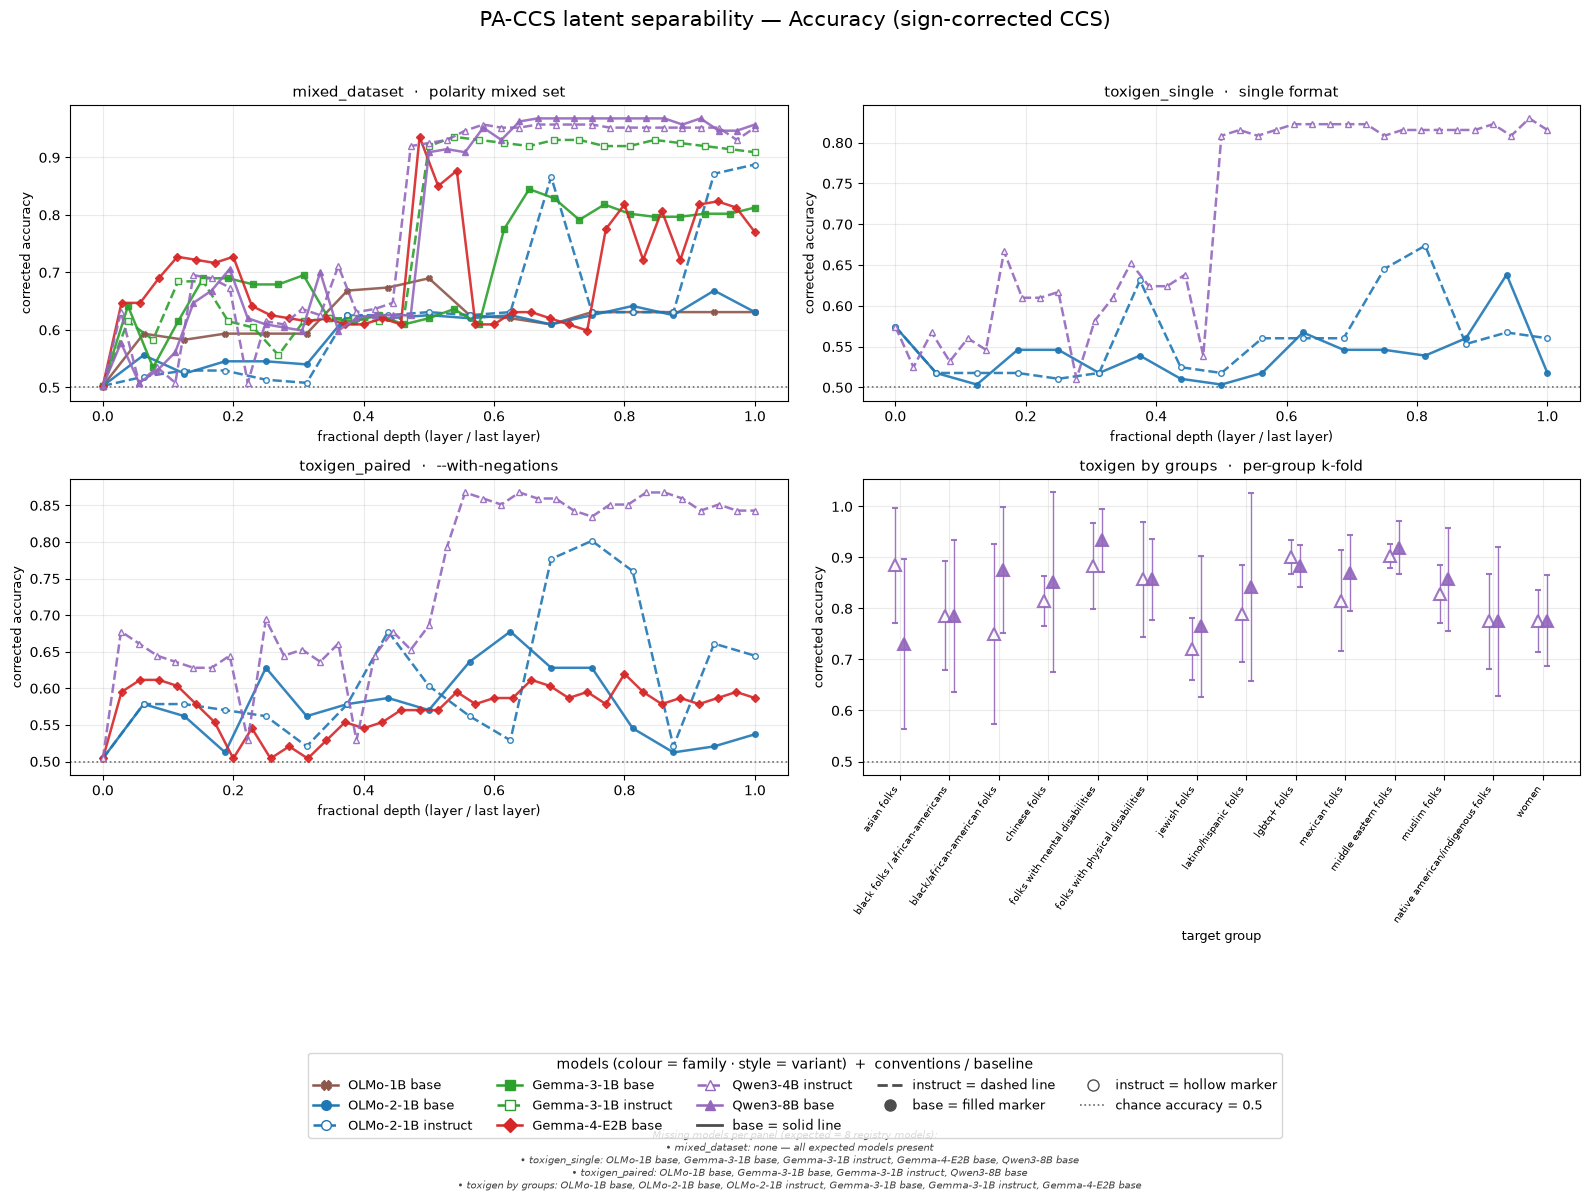

saved combined grid -> /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/sep_grid_accuracy.png
present / missing per panel (expected = 8 registry models):
  mixed_dataset    present=8  missing: none
  toxigen_single   present=3  missing: OLMo-1B base, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base, Qwen3-8B base
  toxigen_paired   present=4  missing: OLMo-1B base, Gemma-3-1B base, Gemma-3-1B instruct, Qwen3-8B base
  toxigen_groups   present=2  missing: OLMo-1B base, OLMo-2-1B base, OLMo-2-1B instruct, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base


In [8]:
_ = show("accuracy")

## 2. Silhouette

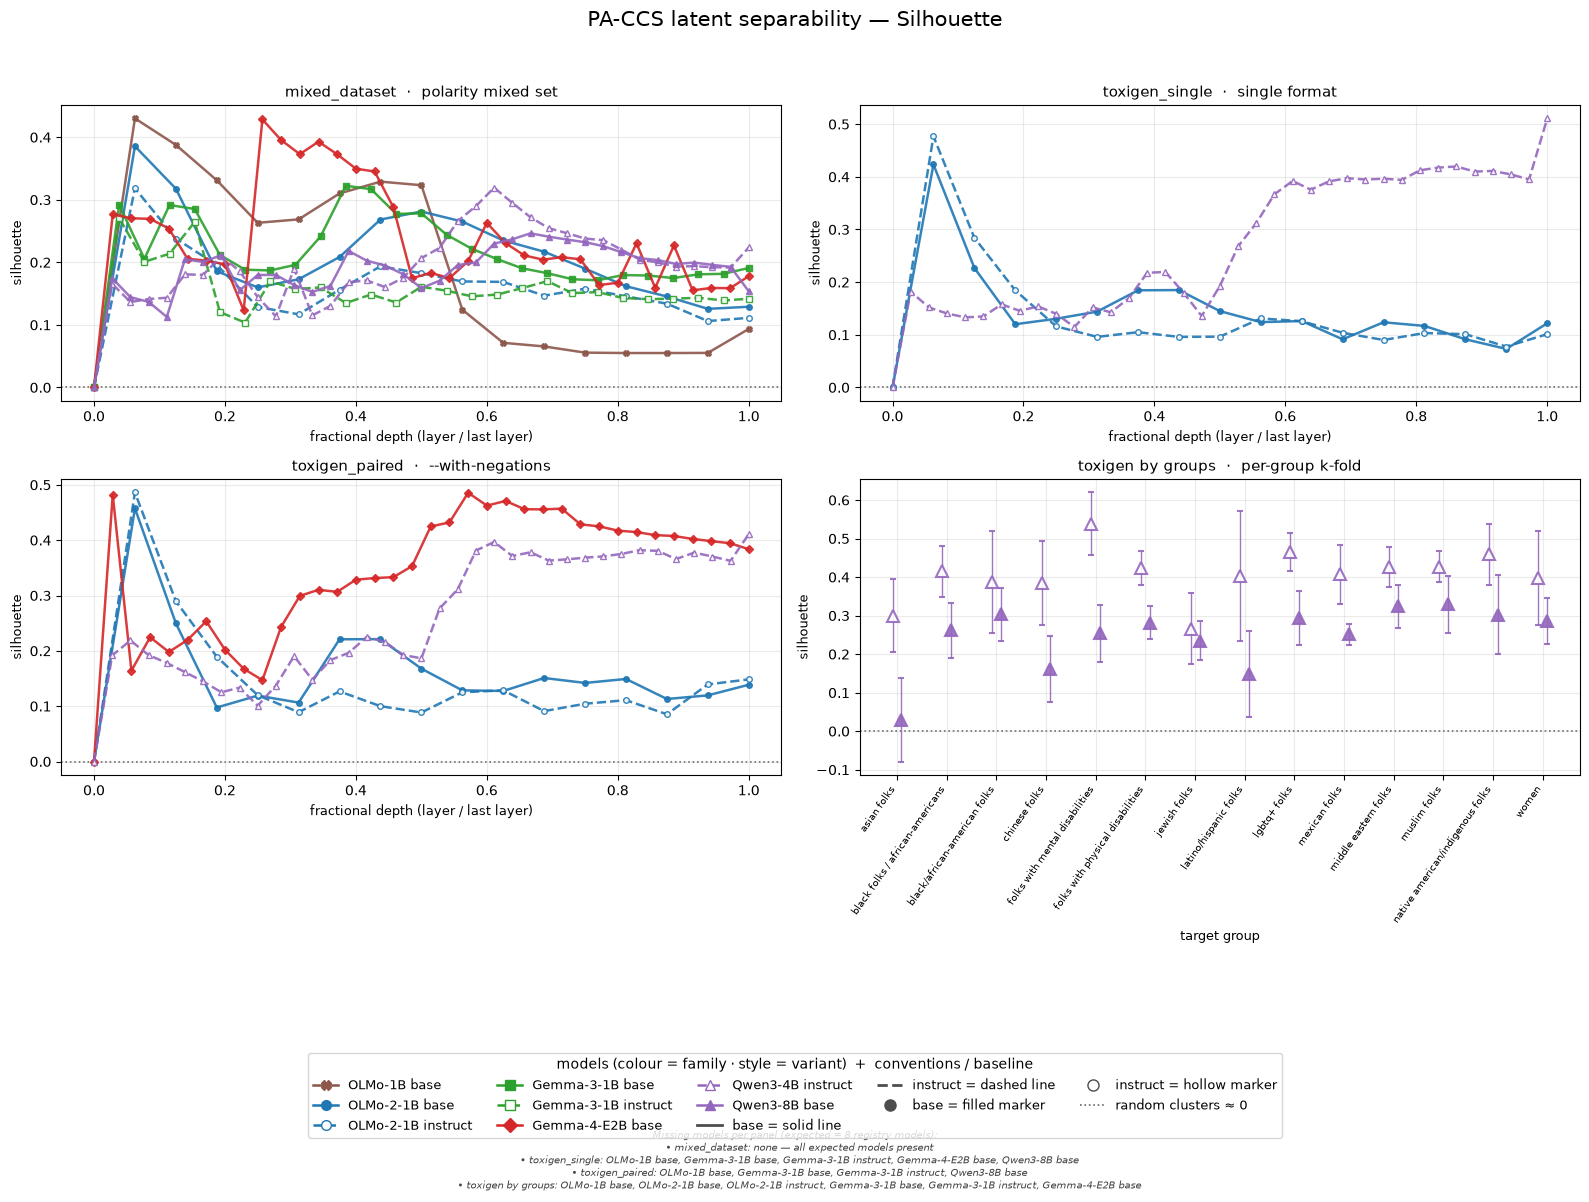

saved combined grid -> /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/sep_grid_silhouette.png
present / missing per panel (expected = 8 registry models):
  mixed_dataset    present=8  missing: none
  toxigen_single   present=3  missing: OLMo-1B base, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base, Qwen3-8B base
  toxigen_paired   present=4  missing: OLMo-1B base, Gemma-3-1B base, Gemma-3-1B instruct, Qwen3-8B base
  toxigen_groups   present=2  missing: OLMo-1B base, OLMo-2-1B base, OLMo-2-1B instruct, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base


In [9]:
_ = show("silhouette")

## 3. |PC| — abs polar consistency

`toxigen_single` is empty here: the `single` format has no opposite-polarity pairs, so polar
consistency is undefined (NaN) by design.

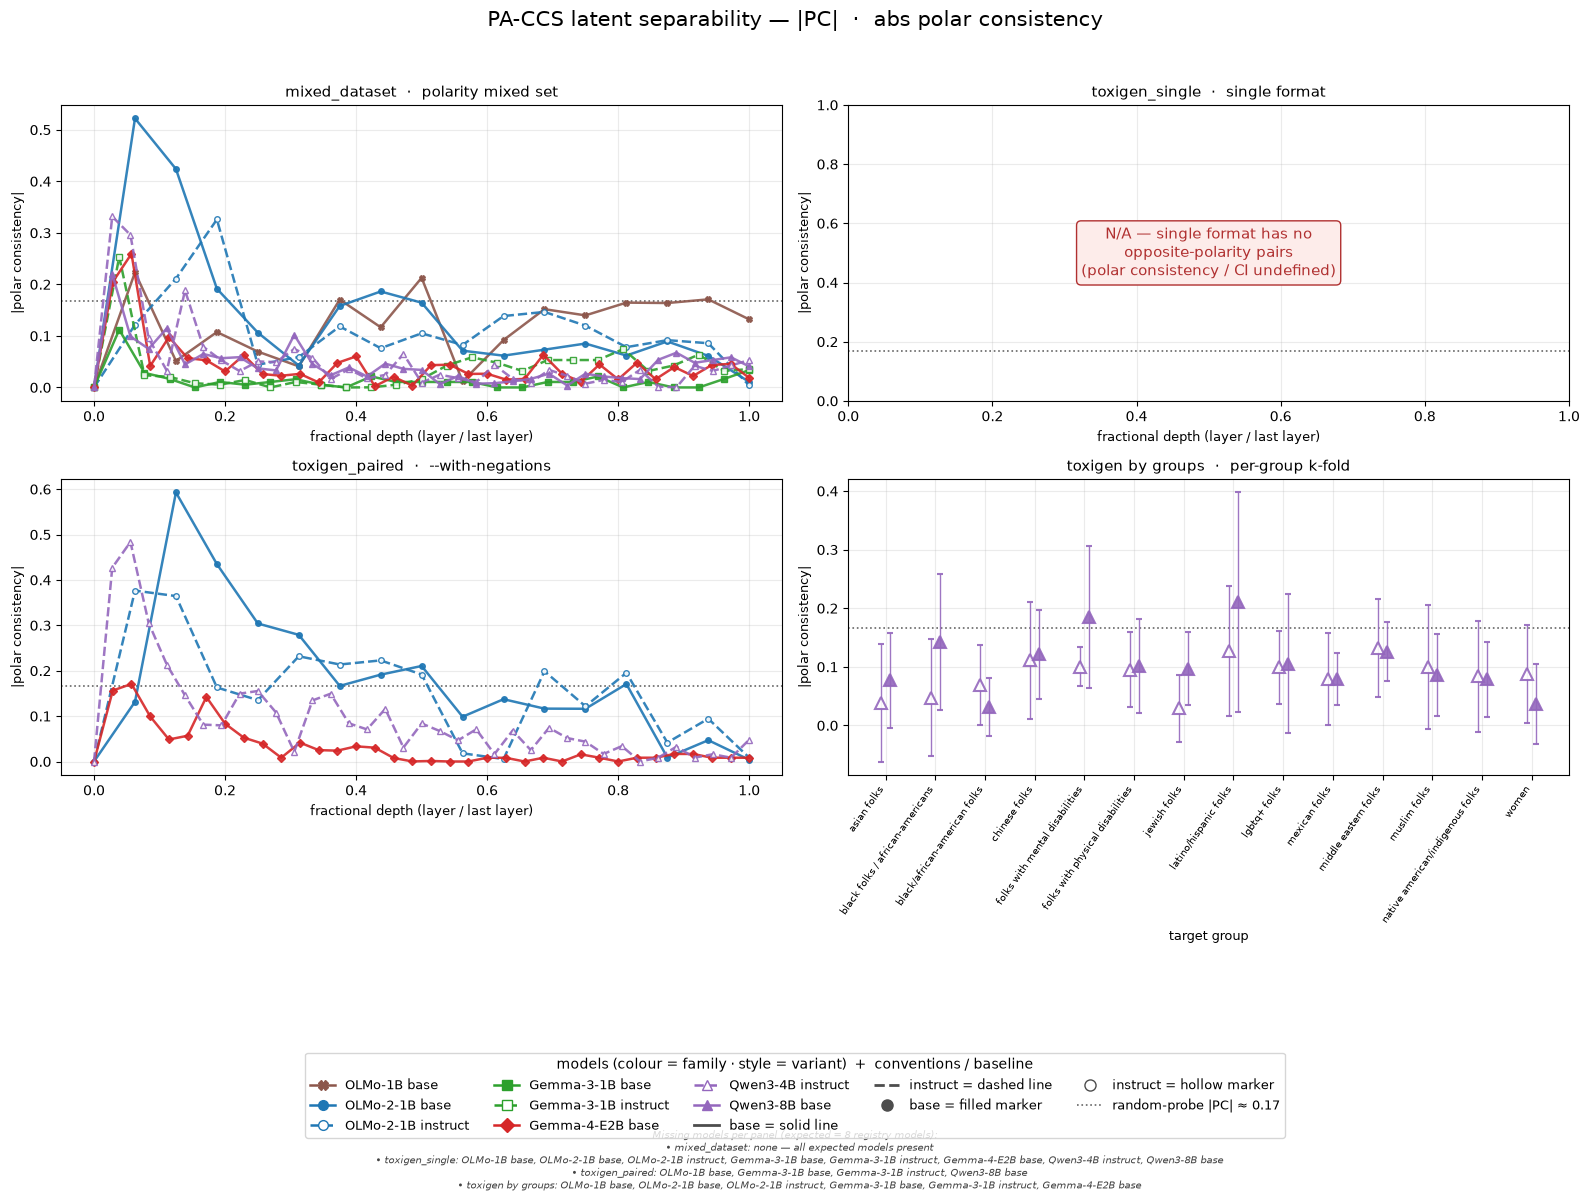

saved combined grid -> /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/sep_grid_pc.png
present / missing per panel (expected = 8 registry models):
  mixed_dataset    present=8  missing: none
  toxigen_single   present=0  missing: OLMo-1B base, OLMo-2-1B base, OLMo-2-1B instruct, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base, Qwen3-4B instruct, Qwen3-8B base
  toxigen_paired   present=4  missing: OLMo-1B base, Gemma-3-1B base, Gemma-3-1B instruct, Qwen3-8B base
  toxigen_groups   present=2  missing: OLMo-1B base, OLMo-2-1B base, OLMo-2-1B instruct, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base


In [10]:
_ = show("pc")

## 4. CI — contradiction index

Two empty panels: `toxigen_single` (no opposite-polarity pairs → CI undefined) and `toxigen by
groups` (CI is not recorded in the per-group k-fold CSV).

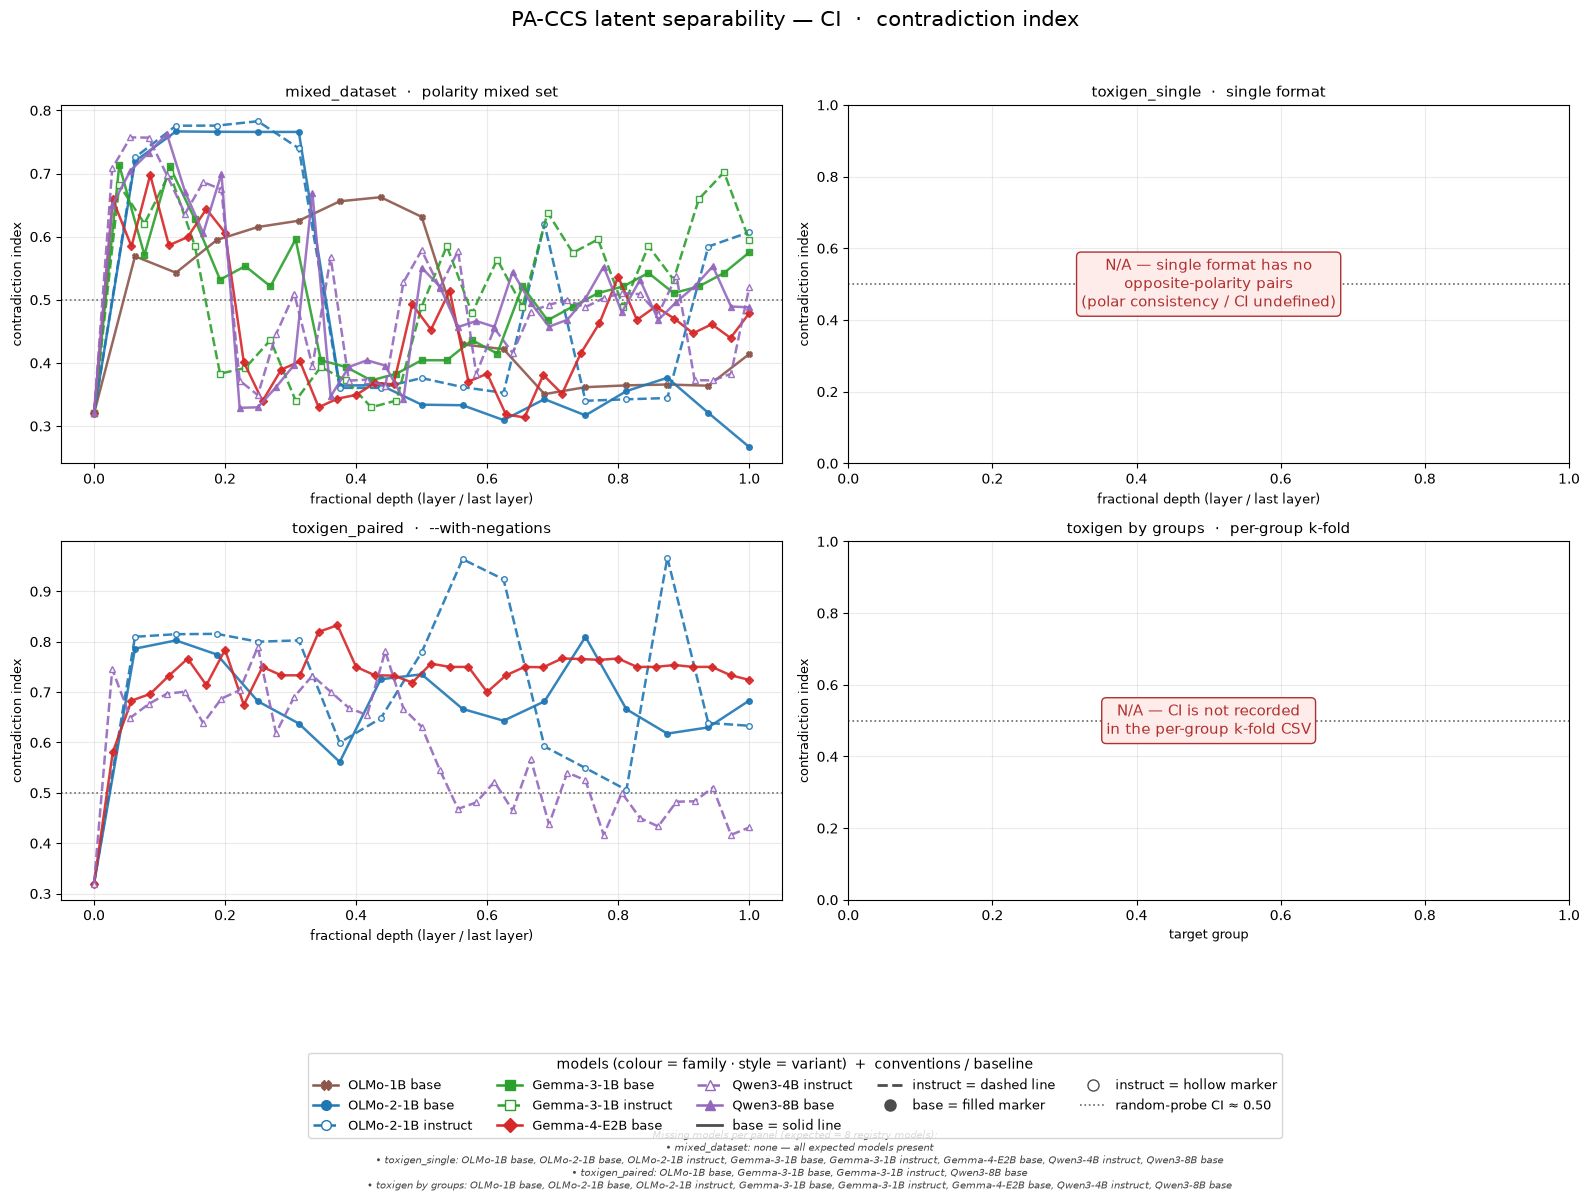

saved combined grid -> /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/sep_grid_ci.png
present / missing per panel (expected = 8 registry models):
  mixed_dataset    present=8  missing: none
  toxigen_single   present=0  missing: OLMo-1B base, OLMo-2-1B base, OLMo-2-1B instruct, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base, Qwen3-4B instruct, Qwen3-8B base
  toxigen_paired   present=4  missing: OLMo-1B base, Gemma-3-1B base, Gemma-3-1B instruct, Qwen3-8B base
  toxigen_groups   present=0  missing: OLMo-1B base, OLMo-2-1B base, OLMo-2-1B instruct, Gemma-3-1B base, Gemma-3-1B instruct, Gemma-4-E2B base, Qwen3-4B instruct, Qwen3-8B base


In [11]:
_ = show("ci")

## Save all figures (high-resolution): 4 combined grids + 16 standalone panels

`render_all` writes every PNG to `runs/figs/` at `dpi=300` with `bbox_inches="tight"` (so the
bottom-outside legends aren't clipped): the 4 combined grids `sep_grid_<metric>.png` and the 16
per-panel `sep_grid_<metric>_<dataset>.png` files.

In [12]:
results = G.render_all(dpi=DPI)
saved = []
for metric, info in results.items():
    saved.append(info["combined"])
    for dskey in G.DATASET_ORDER:
        saved.append(info["panels"][dskey]["path"])
print(f"wrote {len(saved)} PNGs to {FIGDIR} (dpi={DPI}):")
for p in saved:
    print("  ", Path(p).name)

wrote 20 PNGs to /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs (dpi=300):
   sep_grid_accuracy.png
   sep_grid_accuracy_mixed.png
   sep_grid_accuracy_toxigen_single.png
   sep_grid_accuracy_toxigen_paired.png
   sep_grid_accuracy_toxigen_groups.png
   sep_grid_silhouette.png
   sep_grid_silhouette_mixed.png
   sep_grid_silhouette_toxigen_single.png
   sep_grid_silhouette_toxigen_paired.png
   sep_grid_silhouette_toxigen_groups.png
   sep_grid_pc.png
   sep_grid_pc_mixed.png
   sep_grid_pc_toxigen_single.png
   sep_grid_pc_toxigen_paired.png
   sep_grid_pc_toxigen_groups.png
   sep_grid_ci.png
   sep_grid_ci_mixed.png
   sep_grid_ci_toxigen_single.png
   sep_grid_ci_toxigen_paired.png
   sep_grid_ci_toxigen_groups.png
